---
authors:
  - name: Jasper Everink
  - name: Amal Alghamdi (code example contribution)
  
skip_execution: true
---

(regularized_linear_RTO)=
# 1. Regularized linear randomize-then-optimize

In this notebook, we show how to combine deterministic regularization with stochastic priors using a randomize-then-optimize method.

Bayesian priors are a very versatile tool for incorporating prior information, but sometimes priors can become very complicated and computationally expensive to sample from. One way to introduce complicated information, whilst still being able to sample efficiently, is by combining the deterministic effects of regularization from the variational approach to inverse problems with the stochastic effects of Bayesian modeling. A sampling framework that allows for this combination is randomize-then-optimize.

## Table of Contents
* [1.1. Learning objectives](#learning-objectives)
* [1.2. The example problem](#problem)
* [1.3. Efficient sampling through linear randomize-then-optimize](#linear-RTO)
* [1.4. Regularized linear randomize-then-optimize](#regularized-linear-RTO)


## 1.1. Learning objectives <a class="anchor" id="learning-objectives"></a>

After going through this notebook, you will be able to:
- Sample efficiently from Gaussian posterior distributions using linear randomize-then-optimize.
- Add regularization and constraints to a Gaussian distribution using implicit priors.
- Define and run a regularized linear randomize-then-optimize algorithm in CUQIpy.

**Setup:**
We start by importing the necessary modules. 

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from cuqi.testproblem import Deconvolution1D
from cuqi.distribution import Gaussian, JointDistribution, GMRF
from cuqi.implicitprior import ConstrainedGMRF, RegularizedGaussian
from cuqi.sampler import RegularizedLinearRTO, LinearRTO

# Set seed
np.random.seed(24601)

## 1.2. The example problem <a class="anchor" id="problem"></a>

Let us consider the following one-dimensional deconvolution problem:

Text(0.5, 1.0, 'Data')

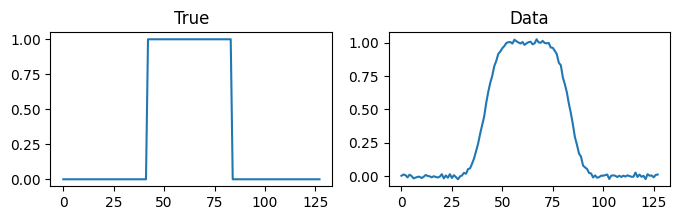

In [2]:
n = 128

x_true = np.zeros(n)
x_true[int(n/3):2*int(n/3)] += 1

A, y_data, info = Deconvolution1D(dim=n, phantom=x_true, PSF_param=5).get_components()

plt.figure(figsize=(8,2))
plt.subplot(1,2,1)
info.exactSolution.plot()
plt.title("True")

plt.subplot(1,2,2)
y_data.plot()
plt.title("Data")

**Note** that the true parameters are very structured, with all values being either 0 or 1, and with only two jumps. We want to incorporate this information in the prior in such a manner that the posterior can still be sampled from efficiently.

## 1.3. Efficient sampling through linear randomize-then-optimize <a class="anchor" id="linear-RTO"></a>

As a preliminary prior, we can choose a multivariate Gaussian distribution, such that we have the following Bayesian problem:

$$
\begin{align*}
\mathbf{x} &\sim \mathrm{Gaussian}(0, \mathbf{\Lambda})\\
\mathbf{y} &\sim \mathrm{Gaussian}(\mathbf{A}\mathbf{x}, \sigma^2\mathbf{I}).
\end{align*}
$$

Using Bayes' rule as usual, we obtain the following posterior probability density function:

$$
p(\mathbf{x} \mid \mathbf{y}_\mathrm{data}) \propto \exp\left(-\tfrac{1}{2\sigma^2}\|\mathbf{A}\mathbf{x}-\mathbf{y}_\mathrm{data}\|_2^2 - \tfrac{1}{2}\mathbf{x}^T\mathbf{\Lambda}^{-1}\mathbf{x}\right).
$$

Specifically, for this example, we will consider a `GMRF` prior. The construction of this prior and associated posterior in CUQIpy goes as follows:

In [3]:
x = GMRF(np.zeros(n), prec=500)
y  = Gaussian(A@x, 0.001)
joint = JointDistribution(x, y)
posterior = joint(y=y_data)

This posterior distribution has a very favourable structure. Recall that a MAP estimator is a solution to the following optimization problem:

$$
\begin{align*}
\mathbf{x}^* &= \underset{\mathbf{x}}{\operatorname{argmax\;}}  -\log p(\mathbf{x} \mid \mathbf{y}_\mathrm{data}) = \underset{\mathbf{x}}{\operatorname{argmin\;}} \frac{1}{2\sigma^2}\|\mathbf{A}\mathbf{x}-\mathbf{y}_\mathrm{data}\|_2^2 + \frac{1}{2}\mathbf{x}^T\mathbf{\Lambda}^{-1}\mathbf{x} 
\end{align*}
$$

This is a linear least-squares problem, for which very efficient optimization algorithms exist to solve them. If possible, we would also like to use these efficient algorithms for sampling. As it turns out, because the posterior distribution is itself a multivariate Gaussian distribution, we can characterize the posterior distribution as the solution to a randomized linear least-squares problem, see {cite}`bardsley2012mcmc`. Specifically, denote by $\mathbf{x}^*$ the posterior random vector, then this random vector can be characterized as follows:

$$
\begin{align*}
\widehat{\mathbf{y}} &\sim \mathrm{Gaussian}(\mathbf{y}_\mathrm{data}, \sigma^2\mathbf{I})\\
\widehat{\mathbf{m}} &\sim \mathrm{Gaussian}(0, \mathbf{\Lambda})\\
\mathbf{x}^* &= \underset{\mathbf{x}}{\operatorname{argmin\;}} \tfrac{1}{2\sigma^2}\|\mathbf{A}\mathbf{x}-\widehat{\mathbf{y}}\|_2^2 + \tfrac{1}{2}(\mathbf{x}-\widehat{\mathbf{m}})^T\mathbf{\Lambda}^{-1}(\mathbf{x}-\widehat{\mathbf{m}})
\end{align*}
$$

We refer to this approach as **linear randomize-then-optimize**. Linear, because we consider linear forward operators, and randomize-then-optimize, because we can obtain an independent posterior sample $\mathbf{x}_i$ by:
1. Sampling a perturbed data vector $\widehat{\mathbf{y}}_i \sim \mathrm{Gaussian}(\mathbf{y}_\mathrm{data}, \sigma^2\mathbf{I})$,
2. Sampling a perturbed prior mean vector $\widehat{\mathbf{m}} \sim \mathrm{Gaussian}(0, \mathbf{\Lambda})$,
3. Solving the randomized MAP estimate $\mathbf{x}_i = \underset{\mathbf{x}}{\operatorname{argmin\;}} \tfrac{1}{2\sigma^2}\|\mathbf{A}\mathbf{x}-\widehat{\mathbf{y}}\|_2^2 + \tfrac{1}{2}(\mathbf{x}-\widehat{\mathbf{m}})^T\mathbf{\Lambda}^{-1}(\mathbf{x}-\widehat{\mathbf{m}})$.

This characterization implies that we can use the efficient algorithms for computing a MAP estimator to sample from the same posterior!

In CUQIpy, we have this algorithm implemented as the `LinearRTO` sampler:

In [4]:
sampler = LinearRTO(posterior) 
sampler.sample(500)
samples = sampler.get_samples()

Sample: 100%|██████████| 500/500 [00:01<00:00, 278.81it/s, acc rate: 100.00%]


Plotting 5 randomly selected samples


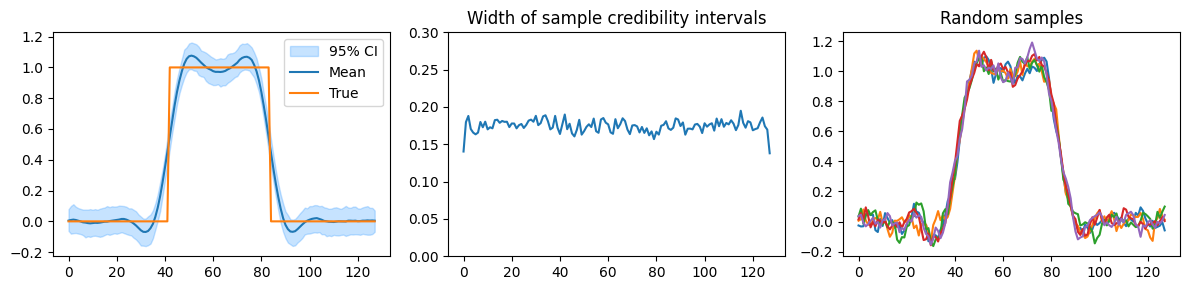

In [5]:
plt.figure(figsize = (12,3))
plt.subplot(1,3,1)
samples.plot_ci()
plt.plot(info.exactSolution)
plt.legend(["95% CI", "Mean", "True"])

plt.subplot(1,3,2)
samples.plot_ci_width()
plt.ylim((0, 0.3))

plt.subplot(1,3,3)
samples.plot()
plt.title("Random samples")

plt.tight_layout()

Notice that the `GMRF` prior has a smoothing effect. The posterior distribution roughly finds the height and location of the bump. However, it does not have the piecewise constant behaviour we know a priori about the true parameters. This is especially noticeable in the large number of fluctuations in the samples. Furthermore, lots of samples have negative values.

## 1.4. Regularized linear randomize-then-optimize <a class="anchor" id="regularized-linear-RTO"></a>

In the Bayesian approach to inverse problems, we use priors to promote certain behaviour. In the context of MAP estimation, or equivalently the variational approach to inverse problems, the term $-\log p(\mathbf{x})$ is referred to as regularization. It therefore makes sense to add such regularization to the linear randomize-then-optimize scheme by adding a non-randomized term $\gamma R(\mathbf{x})$ to the optimization problem. We can also easily incorporate constraints by restricting the optimization problem to $\mathbf{x}\in C$ for some constraint set $C$. We call this approach **regularized linear randomize-then-optimize**, which was introduced in {cite}`everink2023sparse` and such a model takes the form:

$$
\begin{align*}
\widehat{\mathbf{y}} &\sim \mathrm{Gaussian}(\mathbf{y}_\mathrm{data}, \sigma^2)\\
\widehat{\mathbf{m}} &\sim \mathrm{Gaussian}(0, \mathbf{\Lambda})\\
\mathbf{x}^* &= \underset{\mathbf{x}\in C}{\operatorname{argmin\;}} \tfrac{1}{2\sigma^2}\|\mathbf{A}\mathbf{x}-\widehat{\mathbf{y}}\|_2^2 + \tfrac{1}{2}(\mathbf{x}-\widehat{\mathbf{m}})^T\mathbf{\Lambda}^{-1}(\mathbf{x}-\widehat{\mathbf{m}}) + \gamma R(\mathbf{x})
\end{align*}
$$

Sampling from this distribution follows the same steps as before, first sampling from the perturbed data and prior mean vectors, then solving the randomized regularized linear least-squares problem using an efficient optimization algorithm.

Although we assume the computed samples are obtained from a posterior distribution, there usually no easy-to-write prior probability density function that corresponds to this posterior. It is for that reason that we call this underlying prior distribution an implicit prior.

### 1.4.1. Using a prior with nonnegativity constraints

Let us first only apply the constraints to linear randomize-then-optimize. In CUQIpy, this implicit prior is available as the `ConstrainedGaussian` and `ConstrainedGMRF` in the `implicitprior` module, parallel to the `Gaussian` and `GMRF` distributions in the `distribution` module. 

All information for the first randomized term $\tfrac{1}{2\sigma^2}\|\mathbf{A}\mathbf{x}-\widehat{\mathbf{y}}\|_2^2$ in the optimization problem is stored in the likelihood, so we have to provide the implicit prior with the information for the second randomized term $\tfrac{1}{2}(\mathbf{x}-\widehat{\mathbf{m}})^T\mathbf{\Lambda}^{-1}(\mathbf{x}-\widehat{\mathbf{m}})$ and the constraint set $C$.

The `ConstrainedGaussian` and `ConstrainedGMRF` are constructed similarly to their `Gaussian` and `GMRF` counterparts by first providing the mean and the covariance/precision information. This specifies the randomized prior term. Then, additional parameters can be provided to specify the constraints. In this case, we know a priori that the truth is nonnegative. In CUQIpy, this is as simple as setting `constraint` to `"nonnegativity"` when creating your `ConstrainedGaussian` or `ConstrainedGMRF` implicit prior:

In [6]:
x = ConstrainedGMRF(np.zeros(n), prec=500, constraint="nonnegativity")

The precision has been manually tuned to obtain good results.

It is important to understand that the `ConstrainedGaussian` and `ConstrainedGMRF` are not probability distributions and can therefore not be sampled from. It only provides all the information needed to construct the regularized linear randomize-then-optimize problem, which itself can be obtained by constructing a posterior distribution as usual:

In [7]:
y = Gaussian(A@x, 0.001)
posterior = JointDistribution(x, y)(y=y_data)

To sample from the just constructed posterior, we can use the `RegularizedLinearRTO` sampler:

In [8]:
sampler = RegularizedLinearRTO(posterior, maxit=100)
sampler.sample(500)
samples = sampler.get_samples()

Sample: 100%|██████████| 500/500 [00:11<00:00, 45.29it/s, acc rate: 100.00%]


Because this sampler makes use of more complicated optimization algorithms, we can manually tune it by specifying the number of iterations through the `maxit` parameter. The optimization algorithm is automatically chosen depending on the chosen regularization, more details on this and other parameters can be found in the documentation for [`RegularizedLinearRTO`](https://cuqi-dtu.github.io/CUQIpy/api/_autosummary/cuqi.sampler/cuqi.sampler.RegularizedLinearRTO.html).

Plotting 5 randomly selected samples


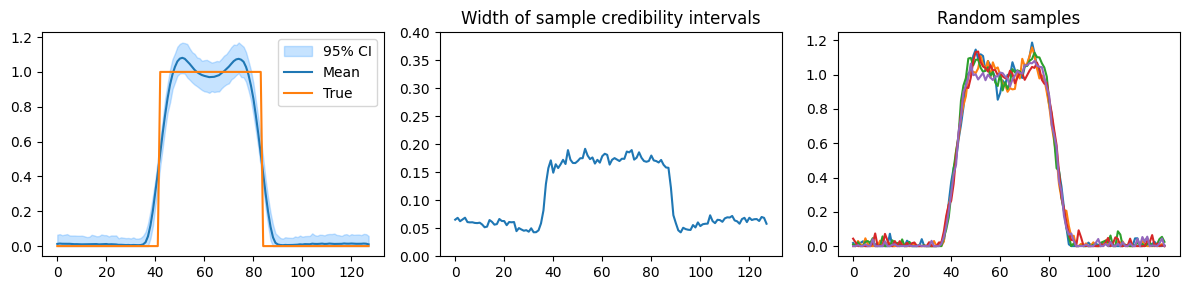

In [9]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
samples.plot_ci()
plt.plot(info.exactSolution)
plt.legend(["95% CI", "Mean", "True"])

plt.subplot(1,3,2)
samples.plot_ci_width()
plt.ylim((0, 0.4))

plt.subplot(1,3,3)
samples.plot()
plt.title("Random samples")

plt.tight_layout()

We can see that this posterior distribution represents the truth far better than the previous `GMRF` prior, because the samples are now always nonnegative. The uncertainty at low-valued coefficients has dropped greatly as seen in the credible interval widths. This informs us that our model knows these low values quite well and is more uncertain about the location of the peak.

### 1.4.2. Nonnegativity constraints and total variation regularization

Nonnegativity constraints alone greatly improve the reconstruction of coefficients at zero, but not the other coefficients at one. One option is to use box constraints instead of nonnegativity. In CUQIpy, this is as simple as replacing `"nonnegativity"` with `"box"`. For the next example, we choose to also include a regularization term $\gamma R(\mathbf{x})$.

A common choice for regularization that promotes piecewise constant signals is total variation regularization of the form $\|\mathbf{D}\mathbf{x}\|_1$, where $\mathbf{D}$ is a linear operator for computing the differences between neighbouring values. This regularization is built into CUQIpy by setting the `regularization` parameter of `RegularizedGaussian` to `'tv'`. To provide $\gamma$, we specify the `strength` parameter. Altogether, this looks as follows in CUQIpy:

In [10]:
x = RegularizedGaussian(np.zeros(n), prec=10, constraint="nonnegativity",
                         regularization='tv', strength=40)

Just like the precision, the strength is manually tuned but could be automatically inferred. And that is all you need to add total variation regularization to the regularized linear randomize-then-optimize algorithm. The remaining steps of constructing the posterior, sampling and plotting are the same as before:

Sample: 100%|██████████| 100/100 [03:32<00:00,  2.12s/it, acc rate: 100.00%]


Plotting 5 randomly selected samples


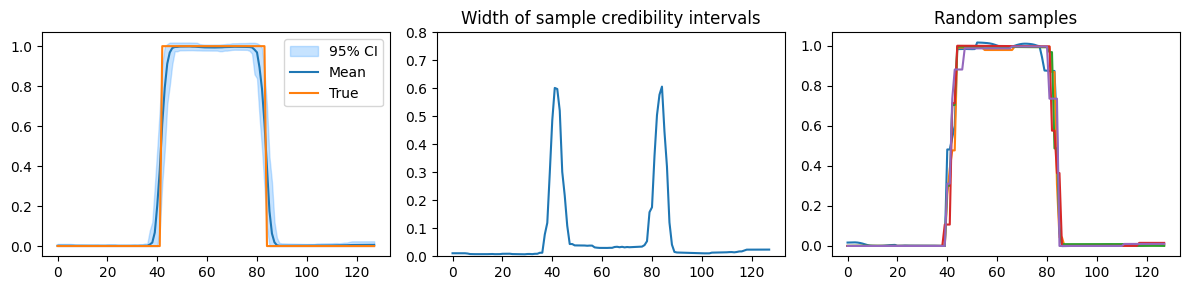

In [11]:
# Construct posterior
y = Gaussian(A@x, 0.001)
posterior = JointDistribution(x, y)(y=y_data)

# Sample
sampler = RegularizedLinearRTO(posterior, maxit=400)
sampler.sample(100)
samples = sampler.get_samples()

# Create figure
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
samples.plot_ci()
plt.plot(info.exactSolution)
plt.legend(["95% CI", "Mean", "True"])

plt.subplot(1,3,2)
samples.plot_ci_width()
plt.ylim((0, 0.8))

plt.subplot(1,3,3)
samples.plot()
plt.title("Random samples")

plt.tight_layout()

Notice how the uncertainty for values close to zero have now dropped significantly to almost zero. Thus, with this prior, the values are indeed close to zero, with some uncertainty about the location and height of the jumps.

Besides total variation regularization and nonnegativity constraints, CUQIpy has options for other regularization functions/constraints, and supports the user specifying their own. A full list of all the supported options can be found in the documentation for [`RegularizedGaussian`](https://cuqi-dtu.github.io/CUQIpy/api/_autosummary/cuqi.implicitprior/cuqi.implicitprior.RegularizedGaussian.html) and additional details are provided in {cite}`everink2025computational`.


:::{admonition} **Reflection**

Reflect on the learning objectives of this notebook. Do you think you have achieved them? If not, what do you think is missing?

:::